# MMM — Exploratory Data Analysis
### Meridian simulated national dataset, 156 weeks

**How to use this.** Each section asks one question, renders the evidence, and stops.
The conclusions are yours to write in the **Your read** cells — that's the whole design.

**Questions, in order**

| # | Question | Why it matters before modeling |
|---|---|---|
| 1 | Is the data complete and regular? | Gaps and duplicates break time-series models silently |
| 2 | What is the outcome doing? | Trend and seasonality compete with media for credit |
| 3 | How is the money split? | Sets which channels can even be meaningfully estimated |
| 4 | What does spend look like week to week? | Flighted vs always-on changes how carryover is identified |
| 5 | Is there enough variation to identify an effect? | A channel that never changes cannot be measured |
| 6 | Are the channels collinear? | Collinearity is the main reason MMMs come out unstable |
| 7 | Do the controls behave? | A control that tracks the outcome will steal media's credit |
| 8 | Is there visible carryover? | Decides whether adstock is warranted, and roughly how long |
| 9 | Is there visible diminishing returns? | The saturation curve is the deliverable — does the data show one? |
| 10 | Are spend and impressions consistent? | Unstable CPM means the two units are not interchangeable |

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- palette (validated: see docs/STRUCTURE.md three-layer + dataviz rules) ---
SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e3e2df"
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
DIVERGING = LinearSegmentedColormap.from_list("bl_rd", [BLUE, "#f0efec", RED])

plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "normal",
    "axes.titlelocation": "left", "figure.dpi": 110, "lines.linewidth": 2,
})

def tidy(ax, title=None, sub=None, ylab=None, pad=None):
    if title: ax.set_title(title, pad=pad or (16 if sub else 6))
    if sub:   ax.text(0, 1.015, sub, transform=ax.transAxes, fontsize=8.5, color=INK2)
    if ylab:  ax.set_ylabel(ylab)
    ax.set_axisbelow(True); ax.grid(axis="x", visible=False)
    return ax

df = pd.read_csv("../data/candidates/meridian_national_all_channels.csv", parse_dates=["time"])
df = df.sort_values("time").reset_index(drop=True)

CH      = [f"Channel{i}" for i in range(5)]
SPEND   = [f"{c}_spend" for c in CH]
IMPR    = [f"{c}_impression" for c in CH]
CONTROL = ["competitor_sales_control", "sentiment_score_control", "Promo"]
df["revenue"] = df.conversions * df.revenue_per_conversion
df["total_spend"] = df[SPEND].sum(axis=1)

print(f"{len(df)} weeks | {df.time.min():%Y-%m-%d} to {df.time.max():%Y-%m-%d}")
df.head(3)

156 weeks | 2021-01-25 to 2024-01-15


,time,conversions,revenue_per_conversion,Channel0_impression,Channel1_impression,Channel2_impression,Channel3_impression,Channel4_impression,Channel0_spend,Channel1_spend,Channel2_spend,Channel3_spend,Channel4_spend,Organic_channel0_impression,competitor_sales_control,sentiment_score_control,Promo,revenue,total_spend
0,2021-01-25,386300926.3,0.020000,44340630,10537596,6501889,66738506,53026011,325137.56830,101595.404270,48315.04518,520082.5242,413173.984050,24028870,-0.032438,-0.342020,0.272211,7.725826e+06,1.408305e+06
1,2021-02-01,355303931.3,0.019990,47391940,30857600,7966320,79000018,27592214,347511.96809,297505.263890,59197.12148,615634.5403,214996.093200,29188267,0.312002,0.807150,0.151264,7.102386e+06,1.534845e+06
2,2021-02-08,438308889.8,0.019993,28960185,23144749,4637739,68442555,20057461,212357.01945,223143.885196,34462.68770,533361.9165,156285.964472,12051369,-1.243697,-0.152005,0.596395,8.763056e+06,1.159611e+06


## 1. Is the data complete and regular?

In [2]:
gaps = df.time.diff().dt.days.value_counts().to_dict()
print("day-steps between rows:", gaps)
print("duplicate weeks      :", df.time.duplicated().sum())
print("missing values       :", int(df.isna().sum().sum()))
print("negative spend       :", int((df[SPEND] < 0).sum().sum()))
print("zero-conversion weeks:", int((df.conversions == 0).sum()))
print()
print(df[["conversions", "revenue_per_conversion", "total_spend"]].describe().T.to_string())

day-steps between rows: {7.0: 155}
duplicate weeks      : 0
missing values       : 0
negative spend       : 0
zero-conversion weeks: 0

                        count          mean           std           min           25%           50%           75%           max
conversions             156.0  4.226328e+08  2.921208e+07  3.402833e+08  4.053507e+08  4.227034e+08  4.404787e+08  4.912874e+08
revenue_per_conversion  156.0  2.000151e-02  1.525580e-05  1.995353e-02  1.999110e-02  2.000121e-02  2.001152e-02  2.004262e-02
total_spend             156.0  1.407003e+06  4.265735e+05  4.198948e+05  1.139011e+06  1.355441e+06  1.660606e+06  2.965465e+06


**Your read:**



## 2. What is the outcome doing?

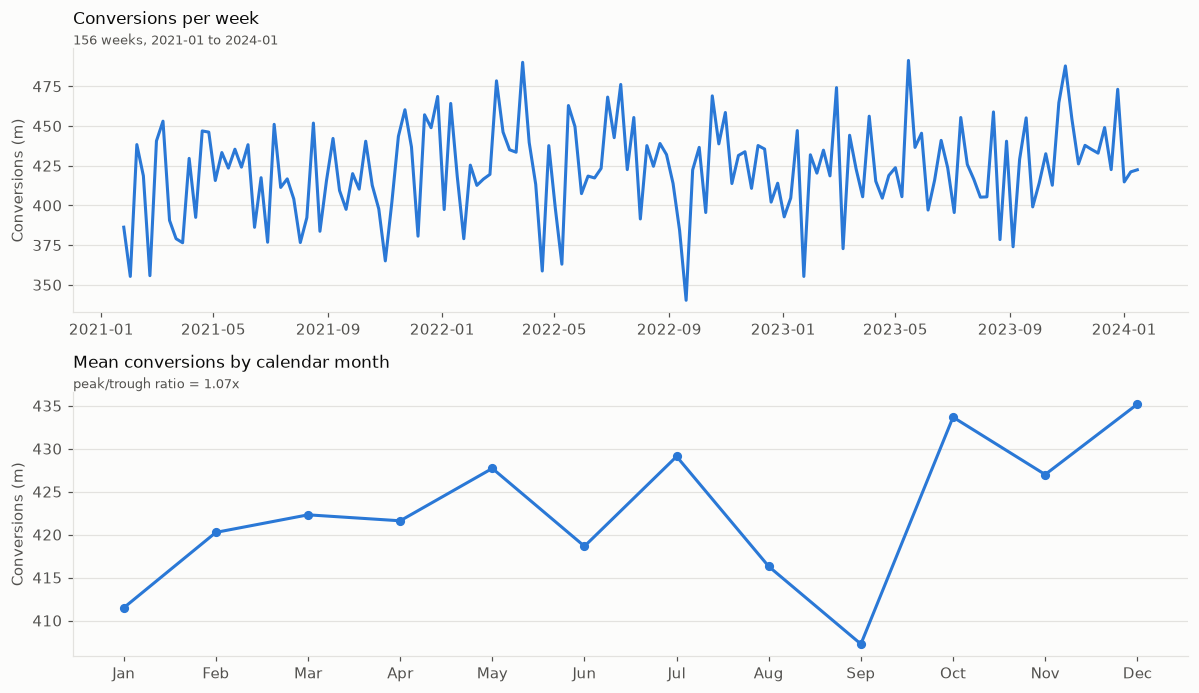

linear trend: 119,322 conversions/week (+1.5% of mean per year)


In [3]:
fig, ax = plt.subplots(2, 1, figsize=(11, 6.4))

ax[0].plot(df.time, df.conversions/1e6, color=BLUE)
tidy(ax[0], "Conversions per week", "156 weeks, 2021-01 to 2024-01", "Conversions (m)")

m = df.groupby(df.time.dt.month).conversions.mean()/1e6
ax[1].plot(m.index, m.values, color=BLUE, marker="o", markersize=5)
ax[1].set_xticks(range(1, 13))
ax[1].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
tidy(ax[1], "Mean conversions by calendar month",
     f"peak/trough ratio = {m.max()/m.min():.2f}x", "Conversions (m)")
plt.tight_layout(); plt.show()

t = np.arange(len(df))
slope, icept = np.polyfit(t, df.conversions, 1)
print(f"linear trend: {slope:,.0f} conversions/week "
      f"({slope*52/df.conversions.mean()*100:+.1f}% of mean per year)")

**Your read:**



## 3. How is the money split across channels?

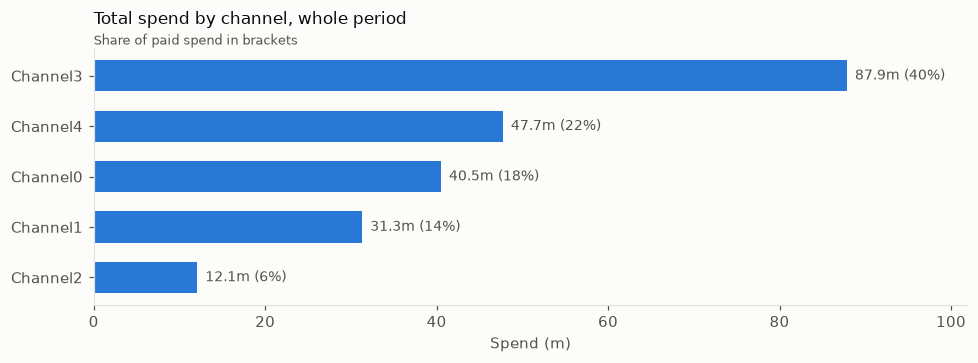

Channel3_spend    40.0
Channel4_spend    21.7
Channel0_spend    18.5
Channel1_spend    14.3
Channel2_spend     5.5 

total paid spend : 219,492,402
total revenue    : 1,318,718,006
spend / revenue  : 16.6%


In [4]:
tot = df[SPEND].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.barh([c.replace("_spend","") for c in tot.index][::-1], (tot/1e6).values[::-1], color=BLUE, height=.62)
for i, v in enumerate((tot/1e6).values[::-1]):
    ax.text(v, i, f"  {v:,.1f}m ({v/(tot.sum()/1e6)*100:.0f}%)", va="center", fontsize=9, color=INK2)
ax.set_xlim(0, (tot/1e6).max()*1.16)
ax.grid(axis="y", visible=False)
tidy(ax, "Total spend by channel, whole period", "Share of paid spend in brackets", "")
ax.set_xlabel("Spend (m)"); plt.tight_layout(); plt.show()

print((tot/tot.sum()).mul(100).round(1).to_string(), "\n")
print(f"total paid spend : {tot.sum():,.0f}")
print(f"total revenue    : {df.revenue.sum():,.0f}")
print(f"spend / revenue  : {tot.sum()/df.revenue.sum():.1%}")

**Your read:**



## 4. What does each channel's spend look like week to week?

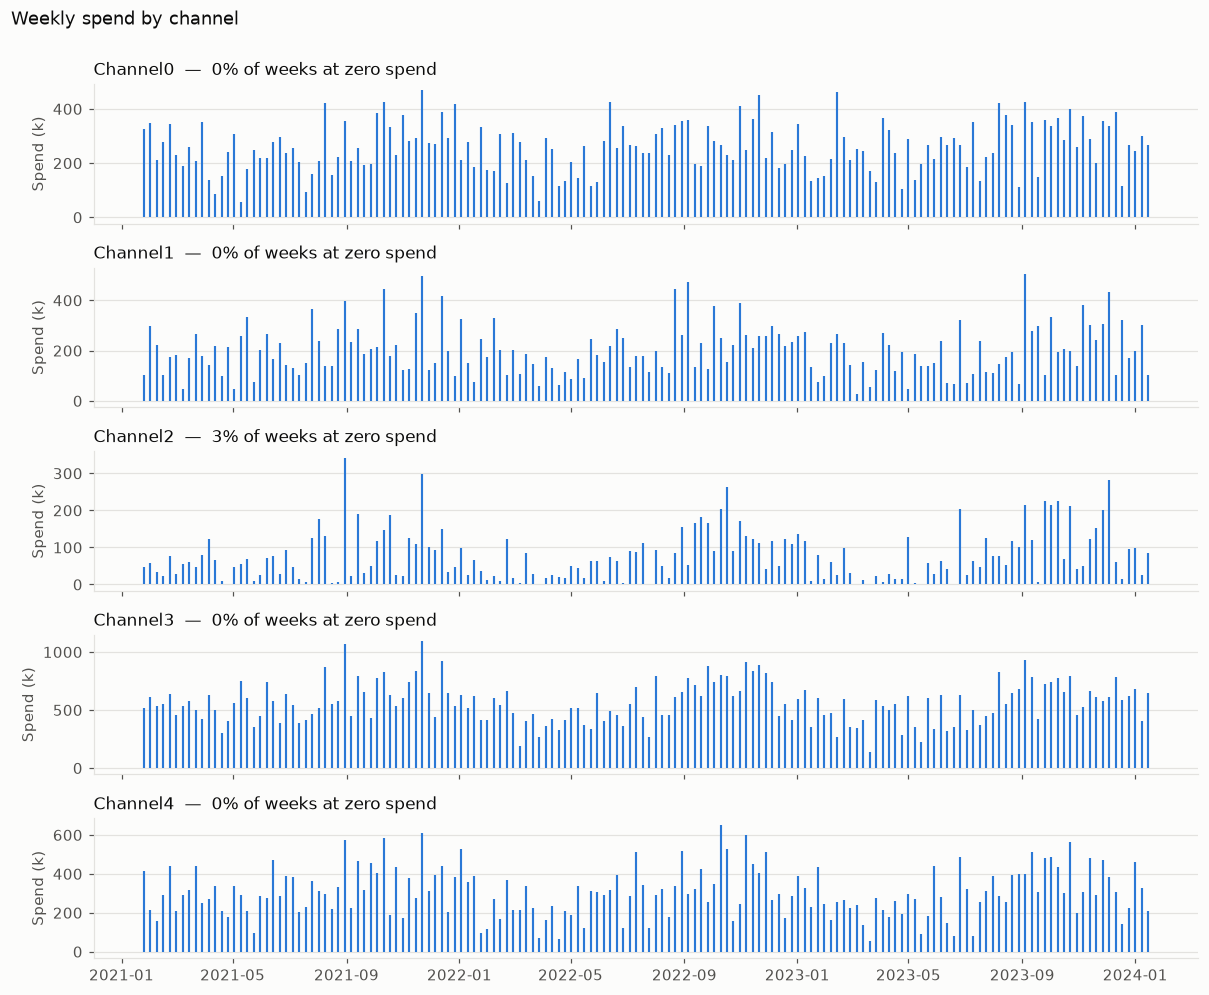

In [5]:
fig, axes = plt.subplots(5, 1, figsize=(11, 9), sharex=True)
for ax, c in zip(axes, CH):
    s = df[f"{c}_spend"]/1e3
    ax.vlines(df.time, 0, s, color=BLUE, linewidth=1.4)
    tidy(ax, f"{c}  —  {(s==0).mean():.0%} of weeks at zero spend", ylab="Spend (k)")
axes[-1].set_xlabel("")
fig.suptitle("Weekly spend by channel", x=0.005, ha="left", y=1.0, fontsize=12)
plt.tight_layout(); plt.show()

**Your read:**



## 5. Is there enough variation to identify an effect?

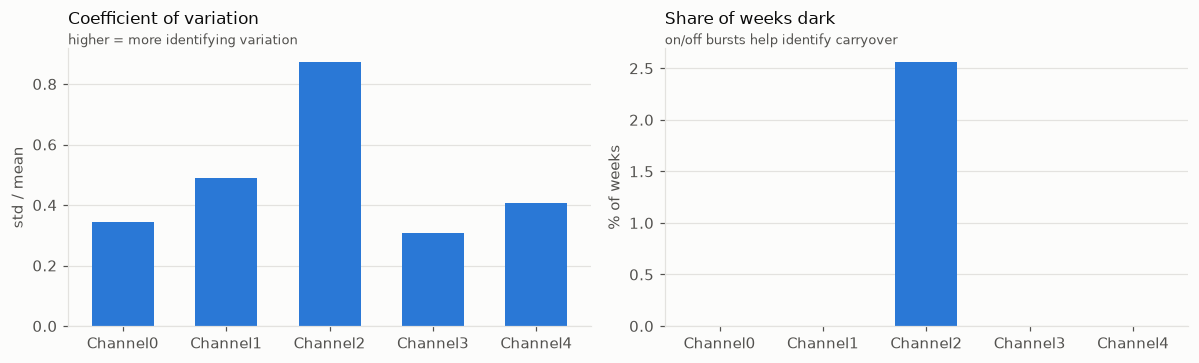

             cv  zero_weeks  p10_p90_ratio
Channel0  0.343       0.000          2.725
Channel1  0.490       0.000          3.451
Channel2  0.874       0.026         20.336
Channel3  0.308       0.000          2.257
Channel4  0.408       0.000          3.042


In [6]:
v = pd.DataFrame({
    "cv": df[SPEND].std()/df[SPEND].mean(),
    "zero_weeks": (df[SPEND]==0).mean(),
    "p10_p90_ratio": df[SPEND].quantile(.9)/df[SPEND].quantile(.1).replace(0, np.nan),
})
v.index = [i.replace("_spend","") for i in v.index]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].bar(v.index, v.cv, color=BLUE, width=.6)
tidy(ax[0], "Coefficient of variation", "higher = more identifying variation", "std / mean")
ax[1].bar(v.index, v.zero_weeks*100, color=BLUE, width=.6)
tidy(ax[1], "Share of weeks dark", "on/off bursts help identify carryover", "% of weeks")
for a in ax: a.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()
print(v.round(3).to_string())

**Your read:**



## 6. Are the channels collinear?

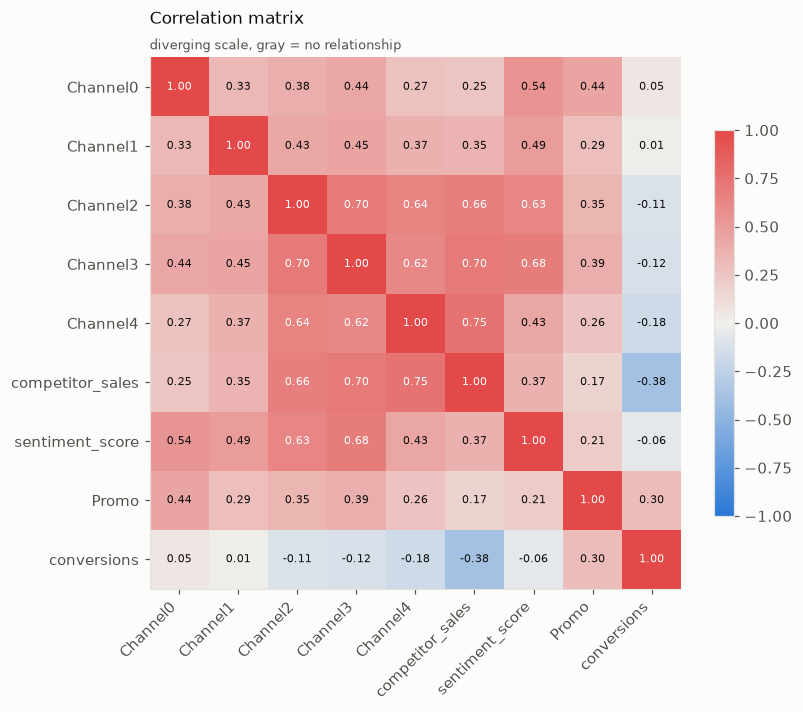

strongest channel-to-channel pair: ('Channel2', 'Channel3') r = 0.700


In [7]:
cols = SPEND + ["competitor_sales_control", "sentiment_score_control", "Promo", "conversions"]
cm = df[cols].corr()
cm.index = cm.columns = [c.replace("_spend","").replace("_control","") for c in cols]

fig, ax = plt.subplots(figsize=(7.6, 6.4))
im = ax.imshow(cm, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(cm))); ax.set_xticklabels(cm.columns, rotation=45, ha="right")
ax.set_yticks(range(len(cm))); ax.set_yticklabels(cm.index)
for i in range(len(cm)):
    for j in range(len(cm)):
        ax.text(j, i, f"{cm.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7.5,
                color=INK if abs(cm.iloc[i,j]) < .55 else "#ffffff")
ax.grid(False)
tidy(ax, "Correlation matrix", "diverging scale, gray = no relationship", pad=22)
fig.colorbar(im, ax=ax, shrink=.72)
plt.tight_layout(); plt.show()

off = cm.loc[[c.replace("_spend","") for c in SPEND], [c.replace("_spend","") for c in SPEND]]
off = off.where(~np.eye(len(off), dtype=bool)).abs().stack()
print(f"strongest channel-to-channel pair: {off.idxmax()} r = {off.max():.3f}")

**Your read:**



## 7. Do the controls behave, or does something dominate the outcome?

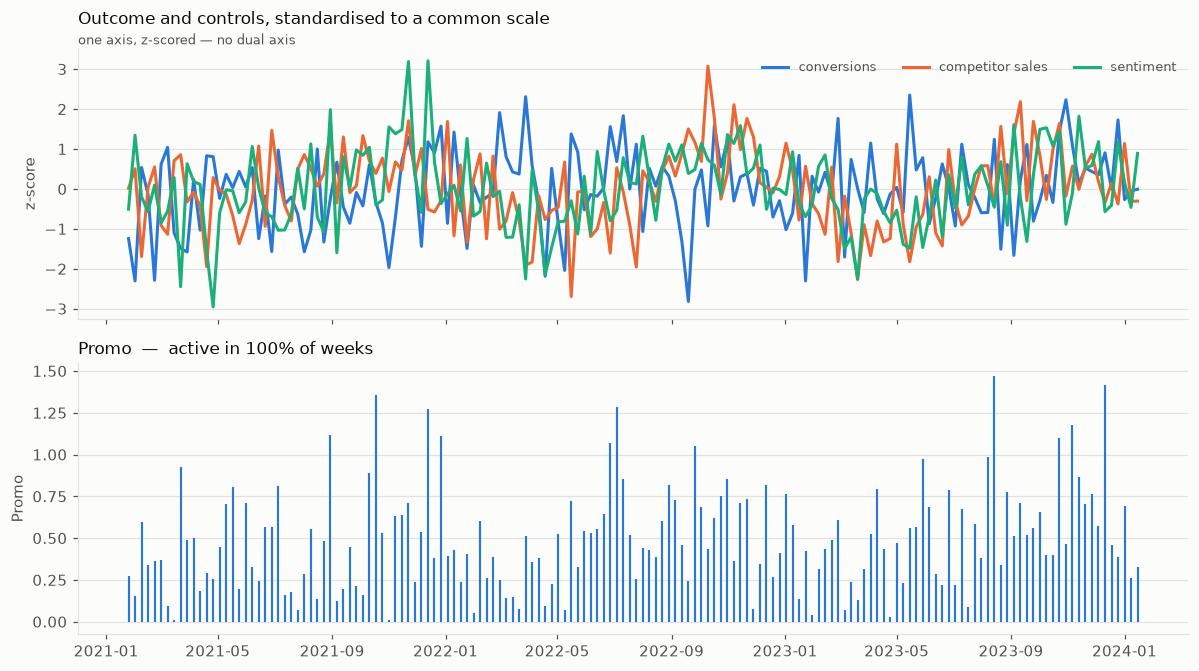

competitor_sales_control   -0.380
sentiment_score_control    -0.056
Promo                       0.299
Channel0_spend              0.051
Channel1_spend              0.012
Channel2_spend             -0.110
Channel3_spend             -0.124
Channel4_spend             -0.179


In [8]:
z = lambda s: (s - s.mean())/s.std()
fig, ax = plt.subplots(2, 1, figsize=(11, 6.2), sharex=True)

ax[0].plot(df.time, z(df.conversions), color=BLUE, label="conversions")
ax[0].plot(df.time, z(df.competitor_sales_control), color=ORANGE, label="competitor sales")
ax[0].plot(df.time, z(df.sentiment_score_control), color=AQUA, label="sentiment")
ax[0].legend(frameon=False, fontsize=8.5, ncol=3, labelcolor=INK2)
tidy(ax[0], "Outcome and controls, standardised to a common scale",
     "one axis, z-scored — no dual axis", "z-score")

ax[1].vlines(df.time, 0, df.Promo, color=BLUE, linewidth=1.4)
tidy(ax[1], f"Promo  —  active in {(df.Promo>0).mean():.0%} of weeks", ylab="Promo")
plt.tight_layout(); plt.show()

print(df[CONTROL + SPEND].corrwith(df.conversions).round(3).to_string())

**Your read:**



## 8. Is there visible carryover?
Correlation of each channel's spend at lag *k* with conversions today.
A peak at k>0, or a slow decay, is a hint that adstock is warranted.

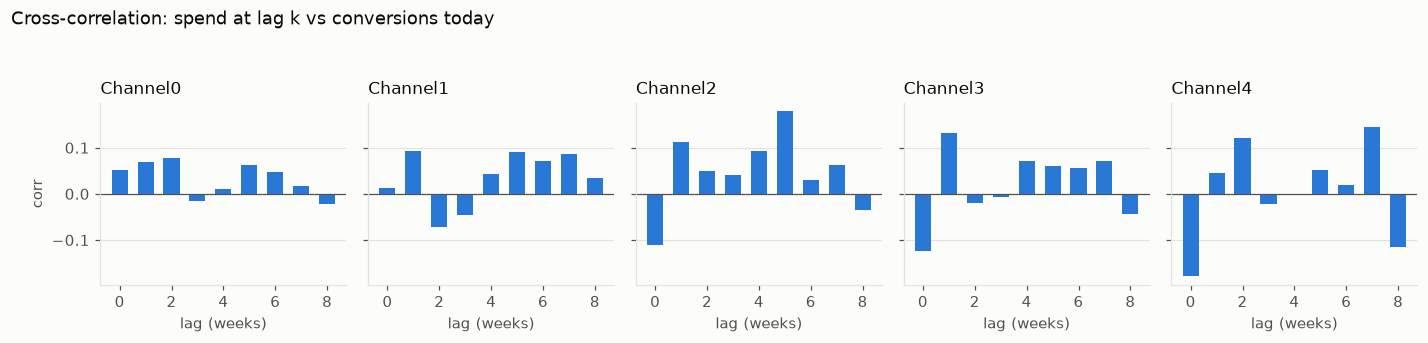

In [9]:
LAGS = range(0, 9)
fig, axes = plt.subplots(1, 5, figsize=(13, 2.9), sharey=True)
for ax, c in zip(axes, CH):
    r = [df[f"{c}_spend"].shift(k).corr(df.conversions) for k in LAGS]
    ax.bar(list(LAGS), r, color=BLUE, width=.62)
    ax.axhline(0, color=INK2, linewidth=.8)
    tidy(ax, c, ylab="corr" if c == "Channel0" else None)
    ax.set_xlabel("lag (weeks)"); ax.grid(axis="x", visible=False)
fig.suptitle("Cross-correlation: spend at lag k vs conversions today",
             x=0.005, ha="left", y=1.06, fontsize=12)
plt.tight_layout(); plt.show()

**Your read:**



## 9. Is there visible diminishing returns?
Weeks binned by spend level; the dot is mean conversions in that bin.
A flattening at the right-hand end is the saturation the model is meant to find.

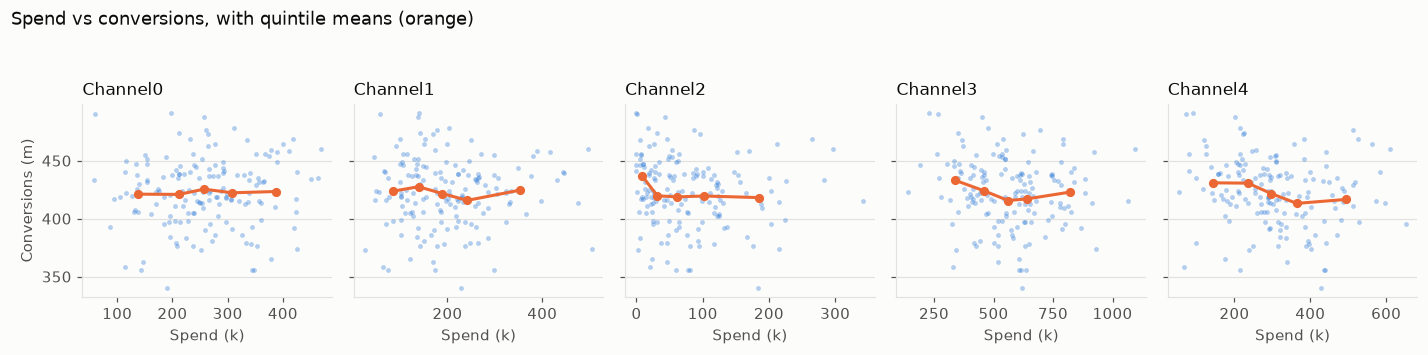

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(13, 3.0), sharey=True)
for ax, c in zip(axes, CH):
    s = df[f"{c}_spend"]
    ax.scatter(s/1e3, df.conversions/1e6, s=10, color=BLUE, alpha=.35, linewidths=0)
    q = pd.qcut(s, 5, duplicates="drop")
    b = df.groupby(q, observed=True).agg(x=(f"{c}_spend","mean"), y=("conversions","mean"))
    ax.plot(b.x/1e3, b.y/1e6, color=ORANGE, marker="o", markersize=5)
    tidy(ax, c, ylab="Conversions (m)" if c == "Channel0" else None)
    ax.set_xlabel("Spend (k)")
fig.suptitle("Spend vs conversions, with quintile means (orange)",
             x=0.005, ha="left", y=1.06, fontsize=12)
plt.tight_layout(); plt.show()

**Your read:**



## 10. Are spend and impressions consistent?

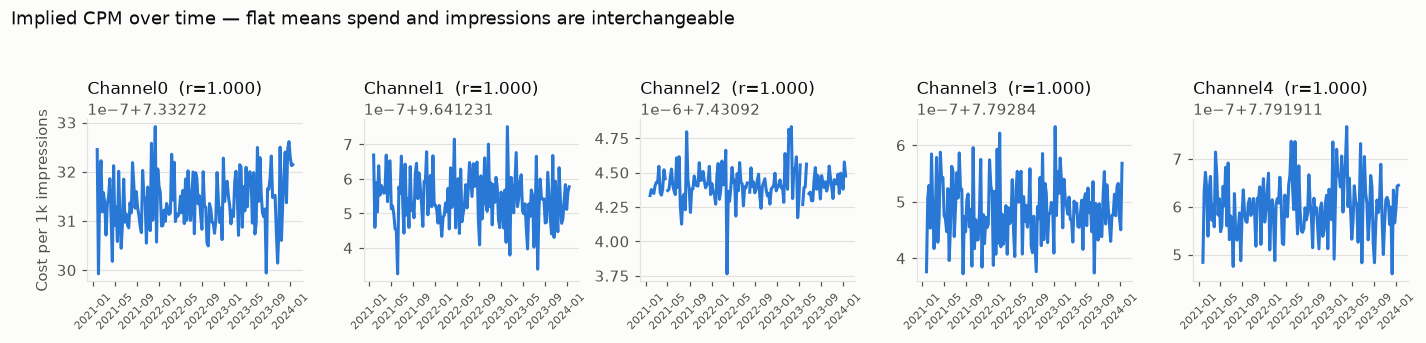

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(13, 2.9), sharex=True)
for ax, c in zip(axes, CH):
    cpm = (df[f"{c}_spend"] / df[f"{c}_impression"].replace(0, np.nan)) * 1000
    ax.plot(df.time, cpm, color=BLUE)
    tidy(ax, f"{c}  (r={df[f'{c}_spend'].corr(df[f'{c}_impression']):.3f})",
         ylab="Cost per 1k impressions" if c == "Channel0" else None)
    ax.tick_params(axis="x", labelrotation=45, labelsize=7)
fig.suptitle("Implied CPM over time — flat means spend and impressions are interchangeable",
             x=0.005, ha="left", y=1.06, fontsize=12)
plt.tight_layout(); plt.show()

**Your read:**



---
## Where this leaves us

Fill in once the sections above are worked through. Anything that turns into a
project decision goes into `DECISIONS.md` — not here.

**Questions this raised that the data can't answer:**

**Things to check before modeling:**